# SETUP - Pin PyTorch version (fix `no kernel image` trên T4/P100)


In [ ]:
# Cell 0: Pin torch/torchvision/torchaudio ổn định cho T4 & P100
# ══════════════════════════════════════════
# Lý do: bản torch mặc định trên Kaggle (vd 2.10.0+cu128) từng gây lỗi
#   "AcceleratorError: CUDA error: no kernel image is available for execution on the device"
#   trên cả T4 (sm_75) và P100 (sm_60), dù get_arch_list() báo có hỗ trợ.
#   -> Hạ về cu121 (ổn định, đã kiểm chứng chạy tốt trên 2 dòng GPU này).
#
# ⚠️ Sau khi cell này chạy xong PHẢI Restart kernel rồi chạy lại từ đầu
#    (không chỉ re-run cell) vì torch cũ đã load vào bộ nhớ.

import subprocess, sys

TORCH_INDEX_URL = "https://download.pytorch.org/whl/cu121"
PINNED_PACKAGES = ["torch", "torchvision", "torchaudio"]

def _run(cmd):
    print(">", " ".join(cmd))
    subprocess.run(cmd, check=True)

_run([sys.executable, "-m", "pip", "uninstall", "-y", *PINNED_PACKAGES])
_run([sys.executable, "-m", "pip", "install", "-q", *PINNED_PACKAGES,
      "--index-url", TORCH_INDEX_URL])

print("\n✅ Đã cài xong. HÃY RESTART KERNEL rồi chạy lại notebook từ đầu.")


## Kiểm tra sau khi Restart Kernel


In [1]:
# Cell 0b: Kiểm tra torch + CUDA sau khi restart kernel
# ══════════════════════════════════════════
import torch

print("torch:", torch.__version__, "| cuda build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Compute capability:", torch.cuda.get_device_capability(0))
    print("Arch list torch hỗ trợ:", torch.cuda.get_arch_list())

    # Test 1 phép tính CUDA thật (không chỉ is_available())
    x = torch.randn(4, 4, device="cuda")
    print("Test matmul OK, sum =", (x @ x).sum().item())
else:
    print("⚠️ Không thấy GPU, kiểm tra lại Accelerator trong Settings.")


torch: 2.5.1+cu121 | cuda build: 12.1
CUDA available: True
GPU: Tesla P100-PCIE-16GB
Compute capability: (6, 0)
Arch list torch hỗ trợ: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']
Test matmul OK, sum = 11.381522178649902


# CONFIG

In [2]:
# Cell 2: Config
# ══════════════════════════════════════════
import torch
import os
TRAIN_ROOT = "/kaggle/input/datasets/minhtranv/msu-mfsd-processed-into-frames/processed/train"
TEST_ROOT = "/kaggle/input/datasets/minhtranv/msu-mfsd-processed-into-frames/processed/test"
# TRAIN_ROOT and TEST_ROOT already set by Cell 1
print(f"Train: {TRAIN_ROOT}")
print(f"Test:  {TEST_ROOT}")

CONF = {
    "lr": 1e-3,
    "epochs": 25,
    "batch_size": 64,
    "width_mult": 0.75,  # 0.75 best
    "num_classes": 2,
    "img_channel": 3,
    "embedding_size": 128,
    "img_size": (80, 80),
    "ft_size": (20, 20), #(20, 20), #(10, 10), #None for feathernet
    "use_ft": True, #False for feathernet

    "cls_weight": 1.0,
    "ft_weight": 0.5,

    "train_root": TRAIN_ROOT,
    "test_root": TEST_ROOT,
    "num_workers": 4,

    "save_dir": "/kaggle/working/",  # /kaggle/working/
    "device": "cuda:0" if torch.cuda.is_available() else "cpu",
}

os.makedirs(CONF["save_dir"], exist_ok=True)
device = torch.device(CONF["device"])
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Train: /kaggle/input/datasets/minhtranv/msu-mfsd-processed-into-frames/processed/train
Test:  /kaggle/input/datasets/minhtranv/msu-mfsd-processed-into-frames/processed/test
Device: cuda:0
GPU: Tesla P100-PCIE-16GB


# DATA LOADER

In [3]:
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms


def get_label_from_filename(filename):
    tag = Path(filename).stem.rsplit("_", 1)[-1].lower()
    if tag == "real": return 1
    elif tag == "fake": return 0
    return None


def find_color_dir(base_dir):
    base = Path(base_dir)
    if (base / "color").is_dir(): return base / "color"
    for sub in base.iterdir():
        if sub.is_dir() and (sub / "color").is_dir(): return sub / "color"
    return base


def detect_dataset_format(root_dir):
    root = Path(root_dir)
    if (root / "real").is_dir() and (root / "attack").is_dir():
        return "msu-mfsd"
    return "casia-fasd"


def sample_frames_from_dir(video_dir, n_frames, seed=None):
    """Lấy ngẫu nhiên tối đa n_frames từ một video folder."""
    exts = {'.png', '.jpg', '.jpeg', '.bmp'}
    frames = sorted([
        f for f in video_dir.iterdir()
        if f.is_file() and f.suffix.lower() in exts
    ])
    if not frames:
        return []
    rng = np.random.RandomState(seed)
    k = min(n_frames, len(frames))
    chosen = rng.choice(len(frames), size=k, replace=False)
    return [frames[i] for i in sorted(chosen)]


def load_msu_mfsd_samples(root_dir, frames_per_video=25, seed=None):
    """MSU-MFSD: real/→1, attack/→0, lấy ngẫu nhiên frames_per_video frames/video."""
    samples = []
    root = Path(root_dir)

    for label_name, label in [("real", 1), ("attack", 0)]:
        label_dir = root / label_name
        if not label_dir.exists():
            continue
        video_dirs = sorted([d for d in label_dir.iterdir() if d.is_dir()])
        for video_dir in video_dirs:
            frames = sample_frames_from_dir(video_dir, frames_per_video, seed=seed)
            for frame in frames:
                samples.append((str(frame), label))

    return samples


def load_casia_fasd_samples(root_dir, frames_per_video=25, seed=None):
    """
    CASIA-FASD: label từ filename.
    Các frames của cùng 1 video thường có cùng prefix → group theo prefix.
    Ví dụ: '10_4.avi_25_fake.jpg', '10_4.avi_30_fake.jpg' → cùng video '10_4.avi'
    """
    exts = {'.png', '.jpg', '.jpeg', '.bmp'}
    color_dir = find_color_dir(Path(root_dir))
    rng = np.random.RandomState(seed)

    # Group frames theo video (prefix trước frame index)
    from collections import defaultdict
    video_groups = defaultdict(list)
    for f in sorted(color_dir.iterdir()):
        if not f.is_file() or f.suffix.lower() not in exts:
            continue
        label = get_label_from_filename(f.name)
        if label is None:
            continue
        # Key = phần tên trước số frame cuối, vd: '10_4.avi_fake'
        parts = f.stem.rsplit("_", 2)  # ['10_4.avi', '25', 'fake']
        video_key = (parts[0], label) if len(parts) >= 3 else (f.stem, label)
        video_groups[video_key].append(f)

    samples = []
    for (video_key, label), frames in video_groups.items():
        k = min(frames_per_video, len(frames))
        chosen = rng.choice(len(frames), size=k, replace=False)
        for i in sorted(chosen):
            samples.append((str(frames[i]), label))

    return samples


class FASDataset(Dataset):
    def __init__(self, root_dir, img_size=(80, 80), ft_size=None,
                 transform=None, is_train=True,
                 frames_per_video=25,   # ← tham số mới
                 seed=42):              # ← seed cho reproducibility
        self.img_size = img_size
        self.ft_size = ft_size

        if transform is not None:
            self.transform = transform
        elif is_train:
            self.transform = transforms.Compose([
                transforms.Resize(img_size),
                transforms.ColorJitter(brightness=0.4, contrast=0.4,
                                       saturation=0.4, hue=0.1),
                transforms.RandomRotation(10),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize(img_size),
                transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3),
            ])

        self.raw_transform = transforms.Compose([
            transforms.Resize(img_size), transforms.ToTensor(),
        ])

        fmt = detect_dataset_format(root_dir)
        load_seed = seed if not is_train else None  # train thì random mỗi lần init
        if fmt == "msu-mfsd":
            self.samples = load_msu_mfsd_samples(root_dir, frames_per_video, seed=load_seed)
        else:
            self.samples = load_casia_fasd_samples(root_dir, frames_per_video, seed=load_seed)

        n_real = sum(1 for _, l in self.samples if l == 1)
        n_fake = sum(1 for _, l in self.samples if l == 0)
        print(f"  [{Path(root_dir).name}] {len(self.samples)} samples "
              f"(real={n_real}, fake={n_fake}) [{fmt}] "
              f"[{frames_per_video} frames/video]")

    def __len__(self):
        return len(self.samples)

    def _compute_ft_map(self, img_tensor):
        gray = 0.299*img_tensor[0] + 0.587*img_tensor[1] + 0.114*img_tensor[2]
        f_shift = np.fft.fftshift(np.fft.fft2(gray.numpy()))
        mag = np.log1p(np.abs(f_shift))
        if mag.max() > mag.min():
            mag = (mag - mag.min()) / (mag.max() - mag.min())
        mag_pil = Image.fromarray((mag * 255).astype(np.uint8))
        mag_pil = mag_pil.resize((self.ft_size[1], self.ft_size[0]), Image.BILINEAR)
        return torch.tensor(np.array(mag_pil, dtype=np.float32) / 255.0).unsqueeze(0)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img_t = self.transform(img)
        if self.ft_size is not None:
            ft = self._compute_ft_map(self.raw_transform(img))
            if np.random.rand() < 0.5:
                _, h, w = ft.shape
                mask_w = np.random.randint(int(w * 0.1), int(w * 0.3) + 1)
                mask_h = np.random.randint(int(h * 0.1), int(h * 0.3) + 1)
                x = np.random.randint(0, w - mask_w + 1)
                y = np.random.randint(0, h - mask_h + 1)
                ft[:, y:y+mask_h, x:x+mask_w] = 0
            return img_t, ft, label
        return img_t, label


# ── Khởi tạo dataset ──────────────────────────────────────────────
ft_size = tuple(CONF["ft_size"]) if CONF["use_ft"] else None

print("Loading data...")
train_dataset = FASDataset(
    CONF["train_root"],
    tuple(CONF["img_size"]),
    ft_size,
    is_train=True,
    frames_per_video=25,  # ← chỉnh ở đây
)
test_dataset = FASDataset(
    CONF["test_root"],
    tuple(CONF["img_size"]),
    ft_size=None,
    is_train=False,
    frames_per_video=30,  # test lấy nhiều hơn một chút để eval ổn định
    seed=42,
)

# ── Balanced sampling ─────────────────────────────────────────────
labels = [s[1] for s in train_dataset.samples]
class_counts = [labels.count(0), labels.count(1)]
class_weights = [1.0 / c for c in class_counts]
sample_weights = [class_weights[l] for l in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(labels), replacement=True)
print(f"  ⚖ Balanced sampling: attack={class_counts[0]}, real={class_counts[1]}")

train_loader = DataLoader(
    train_dataset,
    batch_size=CONF["batch_size"], sampler=sampler,
    num_workers=CONF["num_workers"], pin_memory=True, drop_last=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONF["batch_size"], shuffle=False,
    num_workers=CONF["num_workers"], pin_memory=True)

batch = next(iter(train_loader))
if CONF["use_ft"]:
    real_in_batch = sum(batch[2]==1).item()
    print(f"✓ Batch: img={batch[0].shape}, ft={batch[1].shape}")
    print(f"  Batch balance: real={real_in_batch}, attack={CONF['batch_size']-real_in_batch}")
else:
    real_in_batch = sum(batch[1]==1).item()
    print(f"✓ Batch: img={batch[0].shape}")
    print(f"  Batch balance: real={real_in_batch}, attack={CONF['batch_size']-real_in_batch}")

Loading data...
  [train] 3000 samples (real=750, fake=2250) [msu-mfsd] [25 frames/video]
  [test] 4770 samples (real=1200, fake=3570) [msu-mfsd] [30 frames/video]
  ⚖ Balanced sampling: attack=2250, real=750
✓ Batch: img=torch.Size([64, 3, 80, 80]), ft=torch.Size([64, 1, 20, 20])
  Batch balance: real=23, attack=41


# MxFAS model

In [4]:
# Cell 4: Mbnext Backbone + CDC FTGenerator + Multi-Scale Fusion + SimAM
# ══════════════════════════════════════════
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np


class Conv2d_cd(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1,
                 padding=1, dilation=1, groups=1, bias=False, theta=0.7):
        super(Conv2d_cd, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size,
                              stride=stride, padding=padding, dilation=dilation,
                              groups=groups, bias=bias)
        self.theta = theta

    def forward(self, x):
        out_normal = self.conv(x)
        if math.fabs(self.theta - 0.0) < 1e-8:
            return out_normal
        else:
            [C_out, C_in, kernel_size, kernel_size] = self.conv.weight.shape
            kernel_diff = self.conv.weight.sum(2).sum(2)
            kernel_diff = kernel_diff[:, :, None, None]
            out_diff = F.conv2d(input=x, weight=kernel_diff, bias=self.conv.bias,
                                stride=self.conv.stride, padding=0, groups=self.conv.groups)
            return out_normal - self.theta * out_diff


class simam_module(nn.Module):
    """SimAM: parameter-free spatial+channel attention."""
    def __init__(self, e_lambda=1e-4):
        super(simam_module, self).__init__()
        self.activaton = nn.Sigmoid()
        self.e_lambda = e_lambda

    def forward(self, x):
        b, c, h, w = x.size()
        n = w * h - 1
        x_minus_mu_square = (x - x.mean(dim=[2, 3], keepdim=True)).pow(2)
        y = x_minus_mu_square / (4 * (x_minus_mu_square.sum(dim=[2, 3], keepdim=True) / n + self.e_lambda)) + 0.5
        return x * self.activaton(y)


def _make_divisible(v, divisor, min_value=None):
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v


def conv_3x3_bn(inp, oup, stride):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 3, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.ReLU6(inplace=True)
    )


class SGBlock(nn.Module):
    def __init__(self, inp, oup, stride, expand_ratio, keep_3x3=False):
        super(SGBlock, self).__init__()
        assert stride in [1, 2]

        hidden_dim = inp // expand_ratio
        if hidden_dim < oup / 6.:
            hidden_dim = math.ceil(oup / 6.)
            hidden_dim = _make_divisible(hidden_dim, 16)

        self.identity = False
        self.identity_div = 1
        self.expand_ratio = expand_ratio
        if expand_ratio == 2:
            self.conv = nn.Sequential(
                nn.Conv2d(inp, inp, 3, 1, 1, groups=inp, bias=False),
                nn.BatchNorm2d(inp),
                nn.ReLU6(inplace=True),
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
                nn.ReLU6(inplace=True),
                nn.Conv2d(oup, oup, 3, stride, 1, groups=oup, bias=False),
                nn.BatchNorm2d(oup),
            )
        elif inp != oup and stride == 1 and keep_3x3 == False:
            self.conv = nn.Sequential(
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
                nn.ReLU6(inplace=True),
            )
        elif inp != oup and stride == 2 and keep_3x3 == False:
            self.conv = nn.Sequential(
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
                nn.ReLU6(inplace=True),
                nn.Conv2d(oup, oup, 3, stride, 1, groups=oup, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            if keep_3x3 == False:
                self.identity = True
            self.conv = nn.Sequential(
                nn.Conv2d(inp, inp, 3, 1, 1, groups=inp, bias=False),
                nn.BatchNorm2d(inp),
                nn.ReLU6(inplace=True),
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False),
                nn.BatchNorm2d(hidden_dim),
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
                nn.ReLU6(inplace=True),
                nn.Conv2d(oup, oup, 3, 1, 1, groups=oup, bias=False),
                nn.BatchNorm2d(oup),
            )

    def forward(self, x):
        out = self.conv(x)
        if self.identity:
            shape = x.shape
            id_tensor = x[:, :shape[1]//self.identity_div, :, :]
            out[:, :shape[1]//self.identity_div, :, :] = \
                out[:, :shape[1]//self.identity_div, :, :] + id_tensor
            return out
        else:
            return out


class MXNet(nn.Module):
    def __init__(self, num_classes=1000, width_mult=1., in_channels=3, simam_stages=None):
        super(MXNet, self).__init__()
        self.cfgs = [
            [2,   64, 1, 1],
            [6,   96, 1, 1],
            [6,  128, 3, 2],
            [6,  192, 2, 1],
            [6,  256, 3, 2],
            [6,  384, 2, 1],
            [6,  512, 1, 1],
        ]
        simam_set = set(simam_stages or [])

        input_channel = _make_divisible(32 * width_mult, 4 if width_mult == 0.1 else 8)
        layers = [conv_3x3_bn(in_channels, input_channel, 1)]
        block = SGBlock
        for stage_idx, (t, c, n, s) in enumerate(self.cfgs):
            output_channel = _make_divisible(c * width_mult, 4 if width_mult == 0.1 else 8)
            if c == 1280 and width_mult < 1:
                output_channel = 1280
            layers.append(block(input_channel, output_channel, s, t, n==1 and s==1))
            input_channel = output_channel
            for i in range(n-1):
                layers.append(block(input_channel, output_channel, 1, t))
                input_channel = output_channel
            if stage_idx in simam_set:
                layers.append(simam_module())
        self.features = nn.Sequential(*layers)

        input_channel = output_channel
        output_channel = _make_divisible(input_channel, 4)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(output_channel, num_classes)
        )
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
                if m.bias is not None:
                    m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                m.weight.data.normal_(0, 0.01)
                m.bias.data.zero_()


class FTGenerator(nn.Module):
    """CDC + SimAM FT generator — attention-enhanced frequency extraction."""
    def __init__(self, in_channels=128, out_channels=1, theta=0.7):
        super(FTGenerator, self).__init__()
        self.ft = nn.Sequential(
            Conv2d_cd(in_channels, 128, kernel_size=3, padding=1, bias=False, theta=theta),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            simam_module(),

            Conv2d_cd(128, 64, kernel_size=3, padding=1, bias=False, theta=theta),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            simam_module(),

            Conv2d_cd(64, out_channels, kernel_size=3, padding=1, bias=False, theta=theta),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.ft(x)


class MultiFTNet(nn.Module):
    def __init__(self, num_classes=2, img_channel=3, embedding_size=128,
                 ft_size=None, theta=0.7, width_mult=1.0, **kwargs):
        super(MultiFTNet, self).__init__()
        self.num_classes = num_classes
        self.ft_size = ft_size

        backbone = MXNet(num_classes=num_classes, in_channels=img_channel,
                         width_mult=width_mult)
        features = list(backbone.features.children())

        # 3-way split: shallow / mid / late
        self.shallow_features = nn.Sequential(*features[:3])
        self.mid_features = nn.Sequential(*features[3:6])
        self.late_features = nn.Sequential(*features[6:])

        # Probe actual channel sizes (adapts to any width_mult)
        with torch.no_grad():
            _x = torch.zeros(1, img_channel, 80, 80)
            _shallow = self.shallow_features(_x)
            _mid = self.mid_features(_shallow)
            _late = self.late_features(_mid)
            shallow_ch = _shallow.shape[1]
            mid_ch = _mid.shape[1]
            late_ch = _late.shape[1]

        # Multi-scale fusion: concat(shallow, mid) -> mid_ch via 1x1 conv
        self.fusion_conv = nn.Sequential(
            nn.Conv2d(shallow_ch + mid_ch, mid_ch, 1, 1, 0, bias=False),
            nn.BatchNorm2d(mid_ch),
            nn.ReLU(inplace=True),
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Classification head
        self.linear = nn.Linear(late_ch, embedding_size, bias=False)
        self.bn = nn.BatchNorm1d(embedding_size)
        self.drop = nn.Dropout(p=0.2)
        self.prob = nn.Linear(embedding_size, num_classes, bias=False)

        # CDC + SimAM FTGenerator
        self.FTGenerator = FTGenerator(in_channels=mid_ch, out_channels=1, theta=theta)
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, Conv2d_cd):
                nn.init.kaiming_normal_(m.conv.weight, mode='fan_out', nonlinearity='relu')
                if m.conv.bias is not None:
                    nn.init.constant_(m.conv.bias, 0)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.001)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x_shallow = self.shallow_features(x)
        x_mid = self.mid_features(x_shallow)

        # Classification path (không dùng fusion, không bị ảnh hưởng)
        x_late = self.late_features(x_mid)
        x_late = self.avgpool(x_late)
        x_late = x_late.view(x_late.size(0), -1)
        x_late = self.linear(x_late)
        x_late = self.bn(x_late)
        x_late = self.drop(x_late)
        cls = self.prob(x_late)

        if self.training:
            # Align spatial size rồi concat shallow + mid
            shallow_pooled = F.adaptive_avg_pool2d(x_shallow, x_mid.shape[2:])
            ft_input = self.fusion_conv(torch.cat([shallow_pooled, x_mid], dim=1))
            ft = self.FTGenerator(ft_input)
            if self.ft_size is not None:
                ft = F.interpolate(ft, size=self.ft_size, mode='bilinear', align_corners=False)
            return cls, ft
        else:
            return cls


model = MultiFTNet(
    num_classes=CONF["num_classes"], img_channel=CONF["img_channel"],
    embedding_size=CONF["embedding_size"], ft_size=ft_size, theta=0.7,
    width_mult=CONF.get("width_mult", 1.0),
).to(device)

# Tổng params
total_params = sum(p.numel() for p in model.parameters())

# Inference params = bỏ FTGenerator + fusion_conv (chỉ dùng khi training)
ft_params     = sum(p.numel() for p in model.FTGenerator.parameters())
fusion_params = sum(p.numel() for p in model.fusion_conv.parameters())
inference_params = total_params - ft_params - fusion_params

print(f"✓ MultiFTNet (Multi-Scale Concat + CDC + SimAM)")
print(f"   Total params     : {total_params:,}")
print(f"   Inference params : {inference_params:,}  (−FTGenerator, −fusion_conv)")

✓ MultiFTNet (Multi-Scale Concat + CDC + SimAM)
   Total params     : 447,282
   Inference params : 245,680  (−FTGenerator, −fusion_conv)


# Train/test

In [5]:
# Cell 5: Train (Scaled frequency losses)
# ══════════════════════════════════════════
import time
import random
import numpy as np
from tqdm.notebook import tqdm

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


class SpectralLoss(nn.Module):
    def __init__(self, magnitude_weight=1.0, phase_weight=0.5):
        super().__init__()
        self.mag_w = magnitude_weight
        self.phase_w = phase_weight

    def forward(self, pred, target):
        pred_fft = torch.fft.fft2(pred, norm='ortho')
        target_fft = torch.fft.fft2(target, norm='ortho')
        pred_mag = torch.abs(pred_fft)
        target_mag = torch.abs(target_fft)
        pred_phase = torch.angle(pred_fft)
        target_phase = torch.angle(target_fft)
        return self.mag_w * F.mse_loss(pred_mag, target_mag) + self.phase_w * F.mse_loss(pred_phase, target_phase)


class FocalFrequencyLoss(nn.Module):
    def __init__(self, alpha=1.0):
        super().__init__()
        self.alpha = alpha

    def forward(self, pred, target):
        pred_fft = torch.fft.fft2(pred, norm='ortho')
        target_fft = torch.fft.fft2(target, norm='ortho')
        freq_distance = torch.abs(pred_fft - target_fft)
        weight = freq_distance.detach()
        weight = weight / (weight.mean(dim=(-2, -1), keepdim=True) + 1e-8)
        weight = weight ** self.alpha
        return (weight * freq_distance).mean()


def evaluate(model, loader, device):
    model.eval()
    tp = fp = tn = fn = 0
    with torch.no_grad():
        for batch in loader:
            imgs, labels = batch[0].to(device), batch[-1].to(device)
            _, preds = torch.max(model(imgs), 1)
            for p, g in zip(preds, labels):
                if g==1 and p==1: tp+=1
                elif g==0 and p==1: fp+=1
                elif g==0 and p==0: tn+=1
                else: fn+=1
    total = tp+fp+tn+fn
    acc = (tp+tn)/total if total else 0
    apcer = fp/(tn+fp) if (tn+fp) else 0
    bpcer = fn/(fn+tp) if (fn+tp) else 0
    model.train()
    return acc, apcer, bpcer, (apcer+bpcer)/2


cls_crit = nn.CrossEntropyLoss()
ft_crit = nn.MSELoss()
spectral_crit = SpectralLoss()
focal_freq_crit = FocalFrequencyLoss(alpha=1.0)

W_MSE = 0.3
W_SPECTRAL = 0.1
W_FOCAL = 0.1

optim_ = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-5)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim_, T_max=CONF["epochs"], eta_min=1e-6)

history = {"train_loss":[], "train_acc":[], "test_acc":[], "apcer":[], "bpcer":[], "acer":[]}
best_acer = 1.0

for epoch in range(CONF["epochs"]):
    model.train()
    rloss = rcorr = rtotal = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONF['epochs']}")

    for batch_data in pbar:
        if CONF["use_ft"]:
            imgs, fts, labels = batch_data
            fts = fts.to(device)
        else:
            imgs, labels = batch_data
        imgs, labels = imgs.to(device), labels.to(device)

        optim_.zero_grad()
        if CONF["use_ft"]:
            cls_out, ft_out = model(imgs)
            loss = (CONF["cls_weight"] * cls_crit(cls_out, labels)
                    + W_MSE * ft_crit(ft_out, fts)
                    + W_SPECTRAL * spectral_crit(ft_out, fts)
                    + W_FOCAL * focal_freq_crit(ft_out, fts))
        else:
            cls_out = model(imgs)
            loss = cls_crit(cls_out, labels)

        loss.backward()
        optim_.step()

        _, preds = torch.max(cls_out, 1)
        rtotal += labels.size(0)
        rcorr += (preds==labels).sum().item()
        rloss += loss.item()
        pbar.set_postfix(loss=f"{rloss/(pbar.n+1):.4f}", acc=f"{rcorr/rtotal:.4f}")

    sched.step()
    eloss = rloss/len(train_loader)
    eacc = rcorr/rtotal
    acc, apcer, bpcer, acer = evaluate(model, test_loader, device)

    history["train_loss"].append(eloss); history["train_acc"].append(eacc)
    history["test_acc"].append(acc); history["apcer"].append(apcer)
    history["bpcer"].append(bpcer); history["acer"].append(acer)

    print(f"  Loss:{eloss:.4f} TrainAcc:{eacc:.4f} TestAcc:{acc:.4f} "
          f"APCER:{apcer:.4f} BPCER:{bpcer:.4f} ACER:{acer:.4f}")

    if acer < best_acer:
        best_acer = acer
        torch.save({"epoch":epoch, "model_state_dict":model.state_dict(),
                     "acer":acer, "acc":acc},
                    f"{CONF['save_dir']}/best_model.pth")
        print(f"  ★ Best saved (ACER: {acer:.4f})")

print(f"\n✅ Done! Best ACER: {best_acer:.4f}")


Epoch 1/25:   0%|          | 0/46 [00:00<?, ?it/s]

  Loss:0.7741 TrainAcc:0.7588 TestAcc:0.2516 APCER:1.0000 BPCER:0.0000 ACER:0.5000
  ★ Best saved (ACER: 0.5000)


Epoch 2/25:   0%|          | 0/46 [00:00<?, ?it/s]

  Loss:0.5388 TrainAcc:0.8539 TestAcc:0.5881 APCER:0.5361 BPCER:0.0425 ACER:0.2893
  ★ Best saved (ACER: 0.2893)


Epoch 3/25:   0%|          | 0/46 [00:00<?, ?it/s]

...

  Loss:0.1957 TrainAcc:0.9983 TestAcc:0.8675 APCER:0.0588 BPCER:0.3517 ACER:0.2052


Epoch 24/25:   0%|          | 0/46 [00:00<?, ?it/s]

  Loss:0.1954 TrainAcc:0.9980 TestAcc:0.8631 APCER:0.0672 BPCER:0.3442 ACER:0.2057


Epoch 25/25:   0%|          | 0/46 [00:00<?, ?it/s]

  Loss:0.1940 TrainAcc:0.9986 TestAcc:0.8629 APCER:0.0672 BPCER:0.3450 ACER:0.2061

✅ Done! Best ACER: 0.1350


# EVal

/tmp/ipykernel_131/3627620608.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


✓ Loaded best model from epoch 12 (train ACER: 0.1350)

  Throughput (Inference)
  Single image:  4.81 ms | 208 FPS
  Batch ( 64):   32.85 ms | 1948 FPS

  Test Results
  Accuracy:  0.8824  (4209/4770)
  APCER:     0.1000  (attack→real: 357)
  BPCER:     0.1700  (real→attack: 204)
  ACER:      0.1350
  AUC:       0.9521

Confusion Matrix:
              Pred Attack  Pred Real
  GT Attack       3213        357
  GT Real          204        996


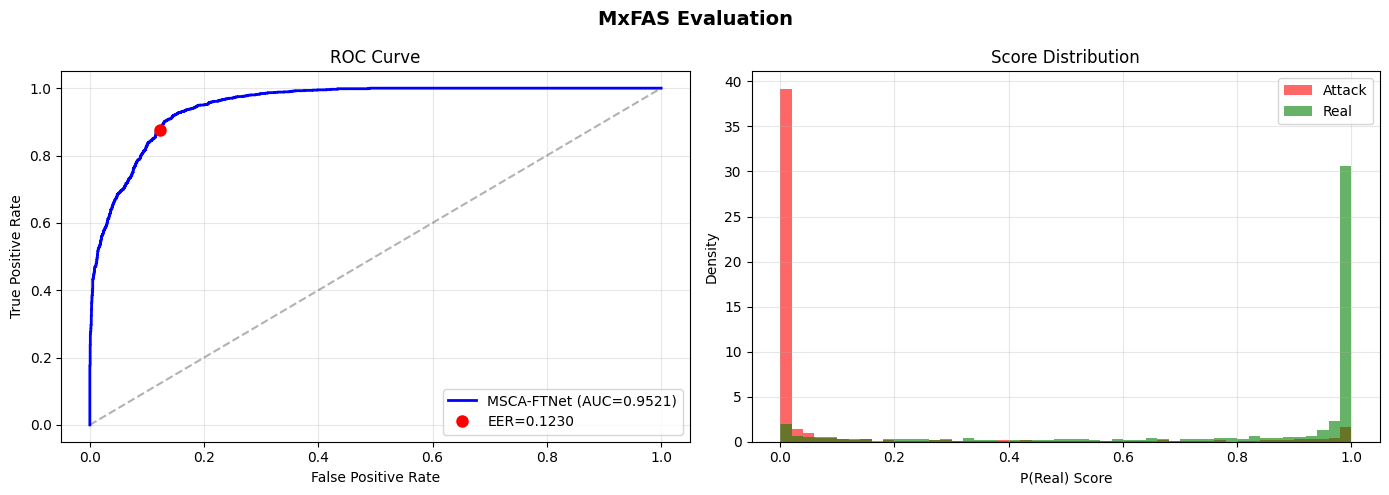


  EER:       0.1230
  Single:    208 FPS (4.81ms)
  Batched:   1948 FPS
  Plot saved to: /kaggle/working//eval_results.png


In [6]:
# Cell 6: Evaluate on Test Set (APCER / BPCER / ACER / AUC / FPS)
# ══════════════════════════════════════════
import torch
import numpy as np
import time
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt

# ── Load best model ──
ckpt_path = f"{CONF['save_dir']}/best_model.pth"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"✓ Loaded best model from epoch {ckpt['epoch']+1} (train ACER: {ckpt['acer']:.4f})")

# ── Throughput / FPS benchmark ──

model.eval()
dummy = torch.randn(1, CONF["img_channel"], *CONF["img_size"]).to(device)

# Warmup
with torch.no_grad():
    for _ in range(50):
        _ = model(dummy)
if torch.cuda.is_available():
    torch.cuda.synchronize()

# Benchmark single image
n_runs = 200
start = time.time()
with torch.no_grad():
    for _ in range(n_runs):
        _ = model(dummy)
if torch.cuda.is_available():
    torch.cuda.synchronize()
single_time = (time.time() - start) / n_runs
single_fps = 1.0 / single_time

# Benchmark batched
batch_size = CONF["batch_size"]
dummy_batch = torch.randn(batch_size, CONF["img_channel"], *CONF["img_size"]).to(device)
start = time.time()
with torch.no_grad():
    for _ in range(50):
        _ = model(dummy_batch)
if torch.cuda.is_available():
    torch.cuda.synchronize()
batch_time = (time.time() - start) / 50
batch_fps = batch_size / batch_time

print(f"\n{'='*50}")
print(f"  Throughput (Inference)")
print(f"{'='*50}")
print(f"  Single image:  {single_time*1000:.2f} ms | {single_fps:.0f} FPS")
print(f"  Batch ({batch_size:>3}):   {batch_time*1000:.2f} ms | {batch_fps:.0f} FPS")

# ── Evaluate metrics ──
all_labels = []
all_preds = []
all_scores = []

with torch.no_grad():
    for batch in test_loader:
        images, labels = batch[0].to(device), batch[-1]
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_scores.extend(probs[:, 1].cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_scores = np.array(all_scores)

tp = np.sum((all_labels == 1) & (all_preds == 1))
fp = np.sum((all_labels == 0) & (all_preds == 1))
tn = np.sum((all_labels == 0) & (all_preds == 0))
fn = np.sum((all_labels == 1) & (all_preds == 0))

total = len(all_labels)
acc = (tp + tn) / total
apcer = fp / (tn + fp) if (tn + fp) > 0 else 0
bpcer = fn / (fn + tp) if (fn + tp) > 0 else 0
acer = (apcer + bpcer) / 2
auc = roc_auc_score(all_labels, all_scores)

print(f"\n{'='*50}")
print(f"  Test Results")
print(f"{'='*50}")
print(f"  Accuracy:  {acc:.4f}  ({tp+tn}/{total})")
print(f"  APCER:     {apcer:.4f}  (attack→real: {fp})")
print(f"  BPCER:     {bpcer:.4f}  (real→attack: {fn})")
print(f"  ACER:      {acer:.4f}")
print(f"  AUC:       {auc:.4f}")
print(f"{'='*50}")

# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds)
print(f"\nConfusion Matrix:")
print(f"              Pred Attack  Pred Real")
print(f"  GT Attack   {cm[0,0]:>8}   {cm[0,1]:>8}")
print(f"  GT Real     {cm[1,0]:>8}   {cm[1,1]:>8}")

# ── ROC Curve ──
fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'MSCA-FTNet (AUC={auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].plot(fpr[eer_idx], tpr[eer_idx], 'ro', markersize=8, label=f'EER={eer:.4f}')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

real_scores = all_scores[all_labels == 1]
attack_scores = all_scores[all_labels == 0]
axes[1].hist(attack_scores, bins=50, alpha=0.6, color='red', label='Attack', density=True)
axes[1].hist(real_scores, bins=50, alpha=0.6, color='green', label='Real', density=True)
axes[1].set_xlabel('P(Real) Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('MxFAS Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONF['save_dir']}/eval_results.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  EER:       {eer:.4f}")
print(f"  Single:    {single_fps:.0f} FPS ({single_time*1000:.2f}ms)")
print(f"  Batched:   {batch_fps:.0f} FPS")
print(f"  Plot saved to: {CONF['save_dir']}/eval_results.png")


# DEMO - Gradio (Auto Face Detect + Crop + Predict)


In [7]:
# Cell 7: Utilities - Face Detect + Crop + Predict
# ══════════════════════════════════════════
import subprocess, sys

def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

try:
    import cv2
except ImportError:
    _pip_install("opencv-python-headless")
    import cv2

import numpy as np
from PIL import Image

# Transform giống lúc train (không augment)
demo_transform = transforms.Compose([
    transforms.Resize(CONF["img_size"]),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])

CLASS_NAMES = {0: "FAKE / SPOOF", 1: "REAL"}

# Haar Cascade có sẵn trong opencv, không cần tải thêm
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

model.eval()


def detect_and_crop_face(pil_img: Image.Image, margin: float = 0.3):
    """
    Phát hiện khuôn mặt lớn nhất trong ảnh và crop kèm margin xung quanh.
    Trả về (cropped_pil_img, box hoặc None, found_face: bool).
    Nếu không tìm thấy mặt, trả về nguyên ảnh gốc.
    """
    img_rgb = pil_img.convert("RGB")
    img_np = np.array(img_rgb)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
    )

    h, w = gray.shape
    if len(faces) == 0:
        return img_rgb, None, False

    # Chọn khuôn mặt lớn nhất (theo diện tích) nếu ảnh có nhiều mặt
    x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])

    mx, my = int(fw * margin), int(fh * margin)
    x1 = max(0, x - mx)
    y1 = max(0, y - my)
    x2 = min(w, x + fw + mx)
    y2 = min(h, y + fh + my)

    cropped = img_rgb.crop((x1, y1, x2, y2))
    return cropped, (x1, y1, x2, y2), True


def predict_face(face_img: Image.Image):
    """Nhận ảnh mặt đã crop (hoặc chưa), trả về (pred, probs numpy[2])."""
    tensor = demo_transform(face_img.convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)[0]
        pred = int(torch.argmax(probs).item())
    return pred, probs.cpu().numpy()


In [8]:
# Cell 8: Gradio Demo - Upload anh chua crop -> tu detect + crop + predict + FFT map + Grad-CAM
# ══════════════════════════════════════════
try:
    import gradio as gr
except ImportError:
    _pip_install("gradio")
    import gradio as gr


def compute_fft_map(pil_img: Image.Image, size: int = 256):
    """
    Tinh pho bien do FFT (log-magnitude spectrum) cua anh, dung de quan sat
    artifact tan so cao (thuong xuat hien ro hon o anh in lai / quay lai man hinh).
    Tra ve PIL Image (grayscale) de hien thi.
    """
    gray = np.array(pil_img.convert("L").resize((size, size)), dtype=np.float32)

    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.log(np.abs(fshift) + 1e-8)

    mmin, mmax = magnitude.min(), magnitude.max()
    norm = (magnitude - mmin) / (mmax - mmin + 1e-8)
    norm_uint8 = (norm * 255).astype(np.uint8)

    return Image.fromarray(norm_uint8)


# ── Grad-CAM: hook vao late_features (feature map cuoi truoc avgpool, dung truc tiep cho cls) ──
_gradcam_activations = {}
_gradcam_gradients = {}


def _save_activation(module, inp, out):
    _gradcam_activations["value"] = out


def _save_gradient(module, grad_in, grad_out):
    _gradcam_gradients["value"] = grad_out[0]


_gradcam_hook_a = model.late_features.register_forward_hook(_save_activation)
_gradcam_hook_g = model.late_features.register_full_backward_hook(_save_gradient)


def compute_gradcam(face_img: Image.Image, target_class: int = None):
    """
    Grad-CAM tren layer late_features. Tra ve PIL Image (RGB) da overlay heatmap
    len anh khuon mat goc, cung voi class duoc dung de tinh CAM.
    """
    tensor = demo_transform(face_img.convert("RGB")).unsqueeze(0).to(device)
    tensor.requires_grad_(True)

    model.zero_grad()
    with torch.enable_grad():
        logits = model(tensor)
        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())
        score = logits[0, target_class]
        score.backward()

    act = _gradcam_activations["value"].detach()[0]      # (C, H, W)
    grad = _gradcam_gradients["value"].detach()[0]        # (C, H, W)
    weights = grad.mean(dim=(1, 2))                       # (C,)
    cam = torch.relu((weights.view(-1, 1, 1) * act).sum(0))
    cam = cam.cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    w, h = face_img.size
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    orig = np.array(face_img.convert("RGB").resize((w, h)))
    overlay = (0.4 * heatmap + 0.6 * orig).astype(np.uint8)

    return Image.fromarray(overlay), target_class


def gradio_predict(input_image):
    if input_image is None:
        return None, None, None, "Vui long chon 1 anh."

    pil_img = input_image if isinstance(input_image, Image.Image) else Image.fromarray(input_image)

    cropped_face, box, found = detect_and_crop_face(pil_img, margin=0.3)
    pred, probs = predict_face(cropped_face)
    fft_map = compute_fft_map(cropped_face)
    gradcam_map, _ = compute_gradcam(cropped_face, target_class=pred)

    label = CLASS_NAMES[pred]
    conf = probs[pred] * 100
    note = "Da tu dong phat hien & crop khuon mat." if found else "Khong phat hien duoc khuon mat - dung nguyen anh goc."

    result_md = (
        f"### {label}  ({conf:.1f}%)\n\n"
        f"- **Real**        : {probs[1]*100:.2f}%\n"
        f"- **Fake/Attack** : {probs[0]*100:.2f}%\n\n"
        f"{note}"
    )
    return cropped_face, gradcam_map, fft_map, result_md


demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil", label="Anh dau vao (chua can crop mat)"),
    outputs=[
        gr.Image(type="pil", label="Khuon mat da tu dong crop"),
        gr.Image(type="pil", label="Grad-CAM (vung anh huong den quyet dinh)"),
        gr.Image(type="pil", label="FFT magnitude spectrum"),
        gr.Markdown(label="Ket qua du doan"),
    ],
    title="MxFAS - Face Anti-Spoofing Demo",
    description=(
        "Tai len 1 anh (chup webcam / anh chua crop) - he thong se tu dong "
        "phat hien khuon mat, crop, tinh Grad-CAM + pho FFT, roi du doan Real hay Fake/Spoof."
    ),
    allow_flagging="never",
)

# share=True de lay link public tam thoi (huu ich tren Kaggle/Colab).
# Doi thanh share=False neu chay may local va khong can link public.
demo.launch(share=True, debug=False)


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://841831c907dc3579c3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 56, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error